In [1]:
import sys
import logging
import random

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Importing necessary modules for data loading and transformation
from data_loader import DASDataLoader, fft

logging.basicConfig(level=logging.INFO)

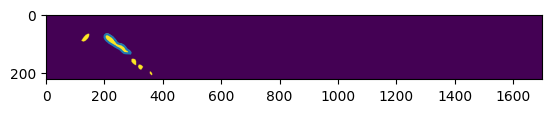

In [2]:
import json
from pprint import pprint

with open("/nobackup/andrei/datasets/DAS-dataset/data/car/auto2_2023-04-17T124510+0100.json") as f:
    data_points = json.load(f)

# pprint(data_points.keys())
# pprint(data_points['curve0'])

# Load data from numpy file
data = np.load("/nobackup/andrei/datasets/DAS-dataset/data/car/auto2_2023-04-17T124510+0100.npy", allow_pickle=True)
# pprint(data)
plt.imshow(data)
x_points = data_points['curve0']['x']
y_points = data_points['curve0']['y']

plt.plot(x_points, y_points)  # Draw shape by connecting points

plt.show()


In [3]:
decim_dict = {
    # The 'regular' label will be decimated by a factor of 50
    'regular': 50,
}

# Initializing the DASDataLoader with dataset parameters
parser = DASDataLoader(
    '/nobackup/andrei/datasets/DAS-dataset/data',  # Path to the dataset directory
    2048,  # Sample length
    transform=fft,  # Applying FFT as a preprocessing step
    fsize=8192,  # Window size for sliding window segmentation
    # Step size for the sliding window (overlap of 75% with fsize=8192)
    shift=2048,
    # Dictionary specifying the decimation factor for each label
    decimate=decim_dict,
)


In [4]:
# Parsing the dataset into features (x) and labels (y)
x, y = parser.parse_dataset()

# Output parsed dataset details
print(x, y)
print(f'The dataset contains {len(x)} elements')

INFO:data_loader:Parsing dataset for label [walk]...
INFO:data_loader:Parsing dataset for label [fence]...
INFO:data_loader:Parsing dataset for label [construction]...
INFO:data_loader:Parsing dataset for label [regular]...
INFO:data_loader:Parsing dataset for label [longboard]...
INFO:data_loader:Parsing dataset for label [openclose]...
INFO:data_loader:Parsing dataset for label [car]...
INFO:data_loader:Parsing dataset for label [manipulation]...
INFO:data_loader:Parsing dataset for label [running]...
INFO:data_loader:Processing file: /nobackup/andrei/datasets/DAS-dataset/data/car/auto2_2023-04-17T124510+0100.h5
INFO:data_loader:Parsing dataset for label [fence]...
INFO:data_loader:Parsing dataset for label [construction]...
INFO:data_loader:Parsing dataset for label [regular]...
INFO:data_loader:Parsing dataset for label [longboard]...
INFO:data_loader:Parsing dataset for label [openclose]...
INFO:data_loader:Parsing dataset for label [car]...
INFO:data_loader:Parsing dataset for la

INFO:data_loader:Processing file: /nobackup/andrei/datasets/DAS-dataset/data/car/auto4_2023-06-06T145055+0100.h5
INFO:data_loader:Processing file: /nobackup/andrei/datasets/DAS-dataset/data/longboard/longboard_2023-04-17T123543+0100.h5
INFO:data_loader:Processing file: /nobackup/andrei/datasets/DAS-dataset/data/longboard/longboard_2023-04-17T123543+0100.h5
INFO:data_loader:Processing file: /nobackup/andrei/datasets/DAS-dataset/data/fence/fence_2023-04-17T123117+0100.h5
INFO:data_loader:Processing file: /nobackup/andrei/datasets/DAS-dataset/data/fence/fence_2023-04-17T123117+0100.h5
INFO:data_loader:Processing file: /nobackup/andrei/datasets/DAS-dataset/data/fence/plot_2023-11-07T150119Z.h5
INFO:data_loader:Processing file: /nobackup/andrei/datasets/DAS-dataset/data/fence/plot_2023-11-07T150119Z.h5
INFO:data_loader:Processing file: /nobackup/andrei/datasets/DAS-dataset/data/walk/walking_2023-04-17T121933+0100.h5
INFO:data_loader:Processing file: /nobackup/andrei/datasets/DAS-dataset/dat

[[5.6094537 5.097933  4.700012  ... 4.093706  4.3315716 4.1064677]
 [5.5273185 5.331628  5.296272  ... 4.318819  3.751658  4.4795156]
 [4.66952   4.5801835 4.461422  ... 4.1655807 4.2454867 4.2480106]
 ...
 [6.2491736 6.4206333 6.8543096 ... 4.094826  3.808321  3.705519 ]
 [5.9568806 5.6151996 6.0756884 ... 3.258548  4.094016  4.209584 ]
 [4.4336452 4.881655  4.991021  ... 4.2888474 3.7518768 4.1855836]] [[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
The dataset contains 118642 elements


In [5]:
x.shape
# x = x[:, np.newaxis, :]
# x.shape


(118642, 2048)

In [6]:
y.argmax(axis=1)
Y = y.argmax(axis=1)
Y.shape

(118642,)

In [7]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


In [8]:
def get_device():
    """Detect and return best available device (MPS > CUDA > CPU)"""
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple Silicon (MPS)")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device

In [9]:
class SimilarityDataset(Dataset):
    def __init__(self, x, y, pairs_per_sample=2, seed=42, is_training=True):
        self.x = torch.FloatTensor(x)
        self.y = torch.LongTensor(y)
        self.pairs_per_sample = pairs_per_sample
        self.seed = seed
        self.is_training = is_training
        
        # Use different seed for validation to avoid memorization
        if is_training:
            self.rng = np.random.RandomState(seed)
        else:
            self.rng = np.random.RandomState(seed + 1000)  # Different seed for validation
            
        self.class_indices = {c: np.where(self.y == c)[0] for c in np.unique(self.y)}
        
    def __len__(self):
        return len(self.x) * self.pairs_per_sample
    
    def __getitem__(self, idx):
        anchor_idx = idx % len(self.x)
        anchor_sample = self.x[anchor_idx]
        anchor_label = self.y[anchor_idx].item()

        if self.rng.rand() < 0.5:
            # Positive pair (same class)
            positive_idx = self.rng.choice(self.class_indices[anchor_label])
            pair = self.x[positive_idx]
            similarity_label = 1.0
        else:
            # Negative pair (different class)
            negative_classes = [c for c in self.class_indices.keys()
                               if c != anchor_label]
            negative_class = self.rng.choice(negative_classes)
            positive_idx = self.rng.choice(self.class_indices[negative_class])
            pair = self.x[positive_idx]
            similarity_label = 0.0
    
        return anchor_sample, pair, torch.FloatTensor([similarity_label])

In [10]:
dataset = SimilarityDataset(x, Y)
dataset[0]

(tensor([5.6095, 5.0979, 4.7000,  ..., 4.0937, 4.3316, 4.1065]),
 tensor([6.0690, 6.0717, 5.9992,  ..., 4.2231, 4.2040, 4.3018]),
 tensor([1.]))

In [12]:
class EmbeddingNetwork(nn.Module):
    def __init__(self, input_dim=2048, embedding_dim=128):
        super(EmbeddingNetwork, self).__init__()
        self.embedding_dim = embedding_dim
        self.network = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, embedding_dim),
        )
    
    def forward(self, x):
        return self.network(x)
    

In [11]:
class EmbeddingConvNetwork(nn.Module):
    def __init__(self, input_dim=2048, embedding_dim=128):
        super(EmbeddingConvNetwork, self).__init__()
        self.embedding_dim = embedding_dim
        self.network = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, stride=1, padding=0),
            nn.LeakyReLU(),
            nn.MaxPool1d(kernel_size=4),
            nn.Conv1d(64, 256, kernel_size=7, stride=1, padding=0),
            nn.LeakyReLU(),
            nn.MaxPool1d(kernel_size=4),
            nn.Flatten(),
            nn.Linear(256 * 126, 1024),
            nn.ReLU(),
            nn.Linear(1024, embedding_dim),
        )
    
    def forward(self, x):
        # Reshape input from [batch, features] to [batch, channels, length]
        # Conv1d expects [batch, channels, length], so we add a length dimension
        # if x.dim() == 2:
        #     x = x.unsqueeze(-1)  # [batch, 2048] -> [batch, 2048, 1]
        if x.dim() == 2:
            x = x.unsqueeze(1)
            
        # Case 2: Input is (Batch, Length, 1) -> Permute to (Batch, 1, Length)
        # Some datasets put channels last; PyTorch needs channels second.
        elif x.dim() == 3 and x.shape[2] == 1:
            x = x.permute(0, 2, 1)
        return self.network(x)

embedding_conv_net = EmbeddingConvNetwork(input_dim=2048, embedding_dim=128)

print(embedding_conv_net)


EmbeddingConvNetwork(
  (network): Sequential(
    (0): Conv1d(1, 64, kernel_size=(7,), stride=(1,))
    (1): LeakyReLU(negative_slope=0.01)
    (2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(64, 256, kernel_size=(7,), stride=(1,))
    (4): LeakyReLU(negative_slope=0.01)
    (5): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=32256, out_features=1024, bias=True)
    (8): ReLU()
    (9): Linear(in_features=1024, out_features=128, bias=True)
  )
)


In [12]:
class SimilarityHead(nn.Module):
    def __init__(self, embedding_network):
        super(SimilarityHead, self).__init__()

        # Embedding dimension to compute similarity features
        embedding_dim = embedding_network.embedding_dim
        
        # Combine multiple similarity measures
        # L1, L2, element-wise product (embedding_dim features), cosine = embedding_dim + 3 features
        combined_dim = embedding_dim + 3
        
        # Learnable weights for different similarity measures (with dropout for regularization)
        self.similarity_weights = nn.Parameter(torch.ones(combined_dim) / combined_dim)
        
        # Combination layer with dropout
        self.combination_layer = nn.Sequential(
            nn.Linear(combined_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),  # Moderate dropout
            nn.Linear(128, 1)
        )

    def forward(self, embedding_1, embedding_2):
        # L1 distance
        l1_distance = torch.sum(torch.abs(embedding_1 - embedding_2), dim=1, keepdim=True)

        # L2 distance
        l2_distance = F.pairwise_distance(embedding_1, embedding_2, keepdim=True)

        # Element-wise product (captures feature interactions)
        element_wise_product = embedding_1 * embedding_2

        # Cosine similarity
        cosine_similarity = F.cosine_similarity(embedding_1, embedding_2, dim=1).unsqueeze(1)

        # Combine all features
        combined_features = torch.cat([l1_distance, l2_distance, element_wise_product, cosine_similarity], dim=1)
        
        # Apply learnable weights
        weighted_features = combined_features * F.softmax(self.similarity_weights, dim=0)
        
        # Final similarity score
        similarity = torch.sigmoid(self.combination_layer(weighted_features))
        
        return similarity

In [ ]:
class SiameseClassifier:
    def __init__(self, input_dim=2048, embedding_dim=128):
        self.device = get_device()
        self.embedding_network = EmbeddingConvNetwork(input_dim, embedding_dim).to(self.device)
        self.similarity_head = SimilarityHead(self.embedding_network).to(self.device)

        self.training_history = {
            'epochs': [],
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': []
        }
        
        self.best_val_acc = 0.0
        self.best_model_state = None
    
    def forward(self, x1, x2):
        embedding_1 = self.embedding_network(x1)
        embedding_2 = self.embedding_network(x2)
        return self.similarity_head(embedding_1, embedding_2)

    def fit(
        self, 
        train_loader, 
        val_loader=None, 
        epochs=200, 
        lr=1e-3, 
        weight_decay=1e-3,
        early_stopping_patience=10,
        log_interval=50
    ):
        import torch
        import torch.nn as nn
        import torch.optim as optim

        self.embedding_network.train()
        self.similarity_head.train()

        criterion = nn.BCELoss()
        optimizer = optim.Adam(
            list(self.embedding_network.parameters()) + list(self.similarity_head.parameters()),
            lr=lr, 
            weight_decay=weight_decay
        )
        
        # Learning rate scheduler - reduce LR when validation loss plateaus
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5
        )
        
        epochs_without_improvement = 0

        for epoch in range(1, epochs + 1):
            train_loss = 0.0
            correct = 0
            total = 0

            for batch_idx, (x1, x2, labels) in enumerate(train_loader):
                x1 = x1.to(self.device)
                x2 = x2.to(self.device)
                labels = labels.float().to(self.device).view(-1, 1)

                optimizer.zero_grad()
                outputs = self.forward(x1, x2)
                loss = criterion(outputs, labels)
                loss.backward()
                
                # Gradient clipping to prevent exploding gradients
                torch.nn.utils.clip_grad_norm_(
                    list(self.embedding_network.parameters()) + list(self.similarity_head.parameters()), 
                    max_norm=1.0
                )
                
                optimizer.step()

                train_loss += loss.item() * x1.size(0)
                preds = (outputs > 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)

                if log_interval and (batch_idx + 1) % log_interval == 0:
                    print(f"Epoch [{epoch}/{epochs}] Batch [{batch_idx+1}/{len(train_loader)}] Loss: {loss.item():.4f}")

            avg_loss = train_loss / total if total > 0 else 0
            train_acc = correct / total if total > 0 else 0

            self.training_history['epochs'].append(epoch)
            self.training_history['train_loss'].append(avg_loss)
            self.training_history['train_acc'].append(train_acc)

            # Evaluate on validation set
            val_acc = None
            val_loss = None
            if val_loader is not None:
                val_loss, val_acc = self.evaluate(val_loader)
                self.training_history['val_loss'].append(val_loss)
                self.training_history['val_acc'].append(val_acc)
                
                # Update learning rate based on validation loss
                old_lr = optimizer.param_groups[0]['lr']
                scheduler.step(val_loss)
                new_lr = optimizer.param_groups[0]['lr']
                if new_lr != old_lr:
                    print(f"  -> Learning rate reduced: {old_lr:.6f} -> {new_lr:.6f}")
                
                # Early stopping logic
                if val_acc > self.best_val_acc:
                    self.best_val_acc = val_acc
                    self.best_model_state = {
                        'embedding_network': self.embedding_network.state_dict(),
                        'similarity_head': self.similarity_head.state_dict()
                    }
                    epochs_without_improvement = 0
                    print(f"  -> New best validation accuracy: {val_acc:.4f}")
                else:
                    epochs_without_improvement += 1
                    
                # Early stopping check
                if early_stopping_patience and epochs_without_improvement >= early_stopping_patience:
                    print(f"\nEarly stopping triggered after {epoch} epochs")
                    print(f"Best validation accuracy: {self.best_val_acc:.4f}")
                    break

            print(f"Epoch {epoch}: Train Loss={avg_loss:.4f} | Train Acc={train_acc:.4f}" +
                  (f" | Val Loss={val_loss:.4f} | Val Acc={val_acc:.4f}" if val_acc is not None else ''))
        
        # Load best model
        if self.best_model_state is not None:
            self.embedding_network.load_state_dict(self.best_model_state['embedding_network'])
            self.similarity_head.load_state_dict(self.best_model_state['similarity_head'])
            print(f"\nLoaded best model with validation accuracy: {self.best_val_acc:.4f}")

    def evaluate(self, data_loader):
        import torch
        self.embedding_network.eval()
        self.similarity_head.eval()
        correct = 0
        total = 0
        total_loss = 0.0
        criterion = nn.BCELoss()

        with torch.no_grad():
            for x1, x2, labels in data_loader:
                x1 = x1.to(self.device)
                x2 = x2.to(self.device)
                labels = labels.float().to(self.device).view(-1, 1)
                outputs = self.forward(x1, x2)
                
                loss = criterion(outputs, labels)
                total_loss += loss.item() * x1.size(0)
                
                preds = (outputs > 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_loss = total_loss / total if total > 0 else 0
        acc = correct / total if total > 0 else 0
        
        self.embedding_network.train()
        self.similarity_head.train()
        return avg_loss, acc
        

In [15]:
set_seed(42)


In [ ]:
# Split dataset into train and validation sets
X_train, X_val, Y_train, Y_val = train_test_split(
    x, Y, 
    test_size=0.2, 
    random_state=42, 
    stratify=Y
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

# Create SimilarityDataset instances for training and validation
train_dataset = SimilarityDataset(X_train, Y_train, pairs_per_sample=2, seed=42)
val_dataset = SimilarityDataset(X_val, Y_val, pairs_per_sample=2, seed=42)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

# Get input dimension from the data
input_dim = x.shape[1]
print(f"Input dimension: {input_dim}")

# Initialize the Siamese Classifier
model = SiameseClassifier(input_dim=input_dim, embedding_dim=1024)

# Train the model
model.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=200,
    lr=1e-3,
    weight_decay=1e-3,
    log_interval=50
)

print("\nTraining completed!")

# Few-Shot Learning Setup

This approach trains on a subset of classes and tests on **unseen classes** to evaluate the model's ability to generalize through similarity matching.

In [16]:
# Check available classes
unique_classes = np.unique(Y)
print(f"Available classes: {unique_classes}")
print(f"Number of classes: {len(unique_classes)}")

# Count samples per class
for cls in unique_classes:
    count = np.sum(Y == cls)
    print(f"  Class {cls}: {count} samples")

Available classes: [0 1 2 3 4 5 6 7 8]
Number of classes: 9
  Class 0: 20957 samples
  Class 1: 29169 samples
  Class 2: 3600 samples
  Class 3: 11908 samples
  Class 4: 17223 samples
  Class 5: 5943 samples
  Class 6: 4201 samples
  Class 7: 12927 samples
  Class 8: 12714 samples


In [17]:
# Split classes into training (seen) and testing (unseen)
# Train on 5 classes, test on 4 unseen classes

# Define which classes to use for training (seen classes)
train_classes = np.array([0, 1, 2, 3, 4])  # First 5 classes
test_classes = np.array([5, 6, 7, 8])      # Last 4 classes (unseen during training)

print(f"Training classes (seen): {train_classes}")
print(f"Testing classes (unseen): {test_classes}")

# Split data by class
train_mask = np.isin(Y, train_classes)
test_mask = np.isin(Y, test_classes)

X_train_classes = x[train_mask]
Y_train_classes = Y[train_mask]

X_test_unseen = x[test_mask]
Y_test_unseen = Y[test_mask]

print(f"\nData separation by class:")
print(f"  SEEN classes data: {len(X_train_classes)} samples from classes {train_classes}")
print(f"  UNSEEN classes data: {len(X_test_unseen)} samples from classes {test_classes}")

# Further split SEEN classes data into train/val (80/20)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_classes, Y_train_classes,
    test_size=0.2,
    random_state=42,
    stratify=Y_train_classes
)

print(f"\nFinal data splits:")
print(f"  X_train: {len(X_train)} samples from SEEN classes {train_classes} (for training)")
print(f"  X_val: {len(X_val)} samples from SEEN classes {train_classes} (held-out validation)")
print(f"  X_test_unseen: {len(X_test_unseen)} samples from UNSEEN classes {test_classes}")
print(f"\n⚠️  Note: Actual testing (in cell 28) will use:")
print(f"     - X_val samples for testing SEEN classes")
print(f"     - X_test_unseen samples for testing UNSEEN classes")

Training classes (seen): [0 1 2 3 4]
Testing classes (unseen): [5 6 7 8]

Data separation by class:
  SEEN classes data: 82857 samples from classes [0 1 2 3 4]
  UNSEEN classes data: 35785 samples from classes [5 6 7 8]

Final data splits:
  X_train: 66285 samples from SEEN classes [0 1 2 3 4] (for training)
  X_val: 16572 samples from SEEN classes [0 1 2 3 4] (held-out validation)
  X_test_unseen: 35785 samples from UNSEEN classes [5 6 7 8]

⚠️  Note: Actual testing (in cell 28) will use:
     - X_val samples for testing SEEN classes
     - X_test_unseen samples for testing UNSEEN classes

Data separation by class:
  SEEN classes data: 82857 samples from classes [0 1 2 3 4]
  UNSEEN classes data: 35785 samples from classes [5 6 7 8]

Final data splits:
  X_train: 66285 samples from SEEN classes [0 1 2 3 4] (for training)
  X_val: 16572 samples from SEEN classes [0 1 2 3 4] (held-out validation)
  X_test_unseen: 35785 samples from UNSEEN classes [5 6 7 8]

⚠️  Note: Actual testing (in 

In [18]:
# Create support set for few-shot evaluation
# Support set contains a few examples (K-shot) from ALL classes for comparison

def create_support_set(X, Y, n_shots=5, seed=42):
    """
    Create a support set with n_shots examples per class.
    This will be used to classify test samples by comparing similarity.
    """
    np.random.seed(seed)
    support_X = []
    support_Y = []
    
    for cls in np.unique(Y):
        cls_indices = np.where(Y == cls)[0]
        # Randomly select n_shots examples from this class
        selected = np.random.choice(cls_indices, size=min(n_shots, len(cls_indices)), replace=False)
        support_X.append(X[selected])
        support_Y.append(Y[selected])
    
    support_X = np.vstack(support_X)
    support_Y = np.concatenate(support_Y)
    
    return support_X, support_Y

# Create support set from ALL classes (both seen and unseen)
# Use the FULL dataset to create support set
n_shots = 5  # Use 5 examples per class as "reference"
X_support_all, Y_support_all = create_support_set(x, Y, n_shots=n_shots)

print(f"Support set created from ALL classes:")
print(f"  Total samples: {len(X_support_all)} ({n_shots} per class)")
print(f"  Classes included: {np.unique(Y_support_all)}")
print(f"  Distribution:")
for cls in np.unique(Y_support_all):
    print(f"    Class {cls}: {np.sum(Y_support_all == cls)} samples")
    
print(f"\nThis support set includes:")
print(f"  - Seen classes (0-4): Classes the model was trained on")
print(f"  - Unseen classes (5-8): Classes the model has NEVER seen")

Support set created from ALL classes:
  Total samples: 45 (5 per class)
  Classes included: [0 1 2 3 4 5 6 7 8]
  Distribution:
    Class 0: 5 samples
    Class 1: 5 samples
    Class 2: 5 samples
    Class 3: 5 samples
    Class 4: 5 samples
    Class 5: 5 samples
    Class 6: 5 samples
    Class 7: 5 samples
    Class 8: 5 samples

This support set includes:
  - Seen classes (0-4): Classes the model was trained on
  - Unseen classes (5-8): Classes the model has NEVER seen


In [19]:
# Few-Shot Classifier: Predicts class by comparing to support set
def few_shot_classify(model, query_samples, support_X, support_Y):
    """
    Classify query samples by comparing similarity with support set.
    
    For each query sample:
    1. Compute similarity with all support samples
    2. Average similarity per class
    3. Predict the class with highest average similarity
    """
    model.embedding_network.eval()
    model.similarity_head.eval()
    
    query_tensor = torch.FloatTensor(query_samples).to(model.device)
    support_tensor = torch.FloatTensor(support_X).to(model.device)
    
    predictions = []
    
    with torch.no_grad():
        for query_idx in range(len(query_samples)):
            query = query_tensor[query_idx:query_idx+1].repeat(len(support_X), 1)
            
            # Compute similarity with all support samples
            similarities = model.forward(query, support_tensor).cpu().numpy().flatten()
            
            # Average similarity per class
            class_similarities = {}
            for cls in np.unique(support_Y):
                cls_mask = support_Y == cls
                class_similarities[cls] = np.mean(similarities[cls_mask])
            
            # Predict class with highest average similarity
            predicted_class = max(class_similarities, key=class_similarities.get)
            predictions.append(predicted_class)
    
    return np.array(predictions)

print("Few-shot classification function defined.")

Few-shot classification function defined.


## Train Model on Seen Classes Only

Now we'll train the Siamese network on only 5 classes (0-4).

**After training**, we'll test on ALL 9 classes (0-8):
- **Seen classes (0-4)**: Should have high accuracy (model trained on these)
- **Unseen classes (5-8)**: TRUE test of generalization (model never saw these)

This tests if similarity learning can recognize completely new classes!

In [20]:
# Create datasets with ONLY the seen classes (0-4)
train_dataset_fewshot = SimilarityDataset(X_train, Y_train, pairs_per_sample=2, seed=42, is_training=True)
val_dataset_fewshot = SimilarityDataset(X_val, Y_val, pairs_per_sample=2, seed=42, is_training=False)

# Create DataLoaders
batch_size = 64
train_loader_fewshot = DataLoader(
    train_dataset_fewshot, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)
val_loader_fewshot = DataLoader(
    val_dataset_fewshot, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"Few-shot training setup:")
print(f"  Training pairs: {len(train_dataset_fewshot):,}")
print(f"  Validation pairs: {len(val_dataset_fewshot):,}")
print(f"  Classes used: {np.unique(Y_train)}")
print(f"  Batch size: {batch_size}")
print(f"\nReady to train on SEEN classes only!")

Few-shot training setup:
  Training pairs: 132,570
  Validation pairs: 33,144
  Classes used: [0 1 2 3 4]
  Batch size: 64

Ready to train on SEEN classes only!


In [ ]:
input_dim = x.shape[1]  
print(f"Input dimension for few-shot model: {input_dim}")

# Initialize a NEW model for few-shot learning
model_fewshot = SiameseClassifier(input_dim=input_dim, embedding_dim=128)

# Train on SEEN classes only (0-4)
print("Training Siamese network on 5 seen classes (0-4)...")
print("This model will later be tested on 4 UNSEEN classes (5-8)\n")

model_fewshot.fit(
    train_loader=train_loader_fewshot,
    val_loader=val_loader_fewshot,
    epochs=200,  # Reduced from 200 since we have fewer classes
    lr=1e-3,
    weight_decay=1e-4,
    log_interval=50
)

print("\n✅ Training on seen classes completed!")

Input dimension for few-shot model: 2048
Using CUDA: NVIDIA GeForce RTX 2080 Ti


Training Siamese network on 5 seen classes (0-4)...
This model will later be tested on 4 UNSEEN classes (5-8)

Epoch [1/200] Batch [50/2072] Loss: 0.6953
Epoch [1/200] Batch [50/2072] Loss: 0.6953
Epoch [1/200] Batch [100/2072] Loss: 0.6909
Epoch [1/200] Batch [100/2072] Loss: 0.6909
Epoch [1/200] Batch [150/2072] Loss: 0.6902
Epoch [1/200] Batch [150/2072] Loss: 0.6902
Epoch [1/200] Batch [200/2072] Loss: 0.6955
Epoch [1/200] Batch [200/2072] Loss: 0.6955
Epoch [1/200] Batch [250/2072] Loss: 0.6900
Epoch [1/200] Batch [250/2072] Loss: 0.6900
Epoch [1/200] Batch [300/2072] Loss: 0.6921
Epoch [1/200] Batch [300/2072] Loss: 0.6921
Epoch [1/200] Batch [350/2072] Loss: 0.6952
Epoch [1/200] Batch [350/2072] Loss: 0.6952
Epoch [1/200] Batch [400/2072] Loss: 0.6936
Epoch [1/200] Batch [400/2072] Loss: 0.6936
Epoch [1/200] Batch [450/2072] Loss: 0.6950
Epoch [1/200] Batch [450/2072] Loss: 0.6950
Epoch [1/200] Batch [500/2072] Loss: 0.6941
Epoch [1/200] Batch [500/2072] Loss: 0.6941
Epoch [1/20

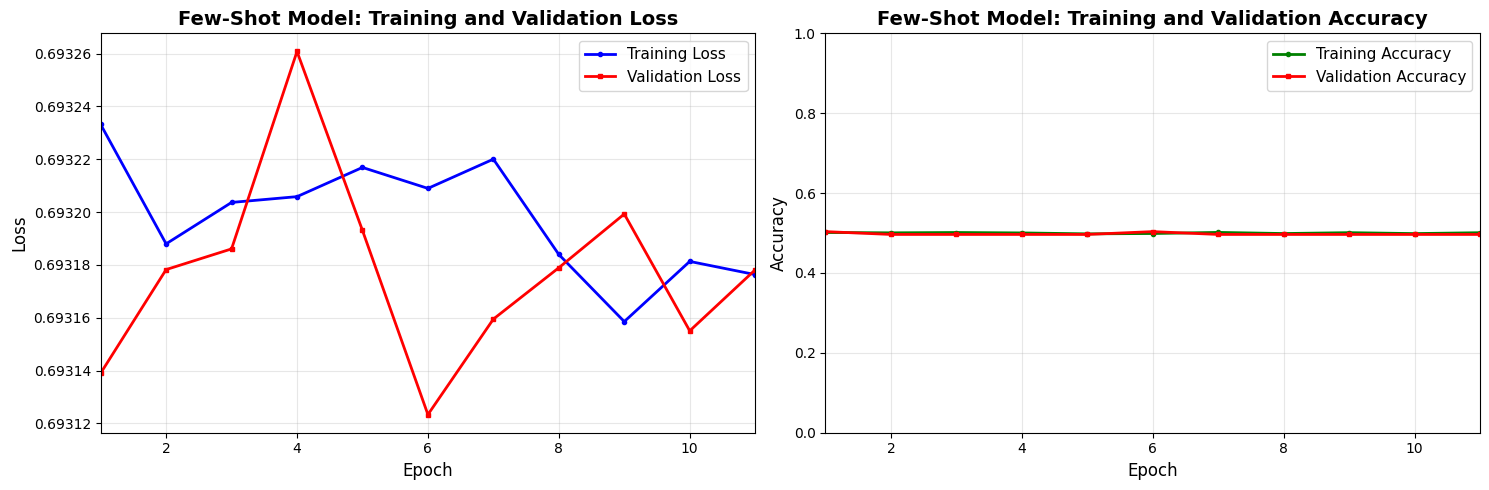


FEW-SHOT MODEL TRAINING SUMMARY (5 Classes)
Total Epochs: 11
Final Training Loss: 0.6932
Final Training Accuracy: 0.5008 (50.08%)
Final Validation Loss: 0.6932
Final Validation Accuracy: 0.4965 (49.65%)
Best Validation Accuracy: 0.5035 (50.35%) at Epoch 1
Overfitting Gap at Best Val: -0.0022 (-0.22%)
  → ✓ Excellent regularization (gap < 5%)


In [23]:
# Plot Few-Shot Model Training History
epochs_fewshot = model_fewshot.training_history['epochs']
train_loss_fewshot = model_fewshot.training_history['train_loss']
train_acc_fewshot = model_fewshot.training_history['train_acc']
val_loss_fewshot = model_fewshot.training_history['val_loss']
val_acc_fewshot = model_fewshot.training_history['val_acc']

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Training and Validation Loss
axes[0].plot(epochs_fewshot, train_loss_fewshot, 'b-', linewidth=2, label='Training Loss', marker='o', markersize=3)
if val_loss_fewshot:
    axes[0].plot(epochs_fewshot, val_loss_fewshot, 'r-', linewidth=2, label='Validation Loss', marker='s', markersize=3)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Few-Shot Model: Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)
axes[0].set_xlim([min(epochs_fewshot), max(epochs_fewshot)])

# Plot 2: Training and Validation Accuracy
axes[1].plot(epochs_fewshot, train_acc_fewshot, 'g-', linewidth=2, label='Training Accuracy', marker='o', markersize=3)
if val_acc_fewshot:
    axes[1].plot(epochs_fewshot, val_acc_fewshot, 'r-', linewidth=2, label='Validation Accuracy', marker='s', markersize=3)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Few-Shot Model: Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)
axes[1].set_ylim([0, 1])
axes[1].set_xlim([min(epochs_fewshot), max(epochs_fewshot)])

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("FEW-SHOT MODEL TRAINING SUMMARY (5 Classes)")
print("="*70)
print(f"Total Epochs: {len(epochs_fewshot)}")
print(f"Final Training Loss: {train_loss_fewshot[-1]:.4f}")
print(f"Final Training Accuracy: {train_acc_fewshot[-1]:.4f} ({train_acc_fewshot[-1]*100:.2f}%)")
if val_acc_fewshot:
    print(f"Final Validation Loss: {val_loss_fewshot[-1]:.4f}")
    print(f"Final Validation Accuracy: {val_acc_fewshot[-1]:.4f} ({val_acc_fewshot[-1]*100:.2f}%)")
    print(f"Best Validation Accuracy: {max(val_acc_fewshot):.4f} ({max(val_acc_fewshot)*100:.2f}%) at Epoch {epochs_fewshot[val_acc_fewshot.index(max(val_acc_fewshot))]}")
    
    # Calculate overfitting gap
    best_val_idx = val_acc_fewshot.index(max(val_acc_fewshot))
    overfitting_gap_fewshot = train_acc_fewshot[best_val_idx] - val_acc_fewshot[best_val_idx]
    print(f"Overfitting Gap at Best Val: {overfitting_gap_fewshot:.4f} ({overfitting_gap_fewshot*100:.2f}%)")
    
    if overfitting_gap_fewshot < 0.05:
        print(f"  → ✓ Excellent regularization (gap < 5%)")
    elif overfitting_gap_fewshot < 0.10:
        print(f"  → ✓ Good regularization (gap < 10%)")
    else:
        print(f"  → ⚠ Moderate overfitting (gap > 10%)")
        
print("="*70)

## Why Did Training Stop at 12 Epochs?

**Early stopping was triggered!** Here's what happened:

1. **Early Stopping Patience = 10**: Training stops if validation accuracy doesn't improve for 10 consecutive epochs
2. Your model likely peaked around epoch 2, then had no improvement for 10 more epochs (3-12)
3. This triggered early stopping at epoch 12

**Possible causes:**
- ✓ Model converged quickly (efficient architecture)
- ⚠️ Learning rate too high (jumped to local optimum)
- ⚠️ Model capacity too low for the task
- ⚠️ Overfitting too quickly

**Solutions to try:**

**Option 1: Increase Early Stopping Patience** (Recommended first)
```python
model_fewshot.fit(..., early_stopping_patience=20)  # or 30
```

**Option 2: Reduce Learning Rate** (If accuracy plateaus early)
```python
model_fewshot.fit(..., lr=5e-4)  # Half of current 1e-3
```

**Option 3: Disable Early Stopping** (To see full 200 epochs)
```python
model_fewshot.fit(..., early_stopping_patience=None)
```

**Option 4: Reduce Regularization** (If underfitting)
```python
model_fewshot.fit(..., weight_decay=5e-4)  # Half of current 1e-3
```

Check the plot below to see exactly when validation accuracy peaked!

## Few-Shot Evaluation on Unseen Classes

Now we'll test the Siamese network on **completely new classes** it has never seen during training!

In [48]:
# Evaluate on ALL classes (both seen and unseen)
# Use proper held-out test sets to avoid data leakage
import time

print("=" * 70)
print("FEW-SHOT LEARNING EVALUATION ON ALL CLASSES")
print("=" * 70)

# Prepare test data: 
# - For SEEN classes (0-4): Use validation set (never used in training)
# - For UNSEEN classes (5-8): Use test_unseen samples

n_samples_per_class = 200  # Limit samples per class for faster evaluation

# Sample from validation set (seen classes)
seen_test_indices = []
for cls in train_classes:
    cls_indices = np.where(Y_val == cls)[0]
    selected = np.random.choice(cls_indices, size=min(n_samples_per_class, len(cls_indices)), replace=False)
    seen_test_indices.extend(selected)

X_test_seen = X_val[seen_test_indices]
Y_test_seen = Y_val[seen_test_indices]

# Sample from unseen test set
unseen_test_indices = []
for cls in test_classes:
    cls_indices = np.where(Y_test_unseen == cls)[0]
    selected = np.random.choice(cls_indices, size=min(n_samples_per_class, len(cls_indices)), replace=False)
    unseen_test_indices.extend(selected)

X_test_unseen_sample = X_test_unseen[unseen_test_indices]
Y_test_unseen_sample = Y_test_unseen[unseen_test_indices]

# Combine both for complete evaluation
X_test_all = np.vstack([X_test_seen, X_test_unseen_sample])
Y_test_all = np.concatenate([Y_test_seen, Y_test_unseen_sample])

print(f"\nTest Configuration:")
print(f"  - Support Set: {len(X_support_all)} samples ({n_shots}-shot per class)")
print(f"  - Test Samples: {len(X_test_all)} samples")
print(f"    • SEEN classes (0-4): {len(X_test_seen)} samples from VALIDATION set")
print(f"    • UNSEEN classes (5-8): {len(X_test_unseen_sample)} samples from TEST set")
print(f"\nTest Distribution:")
for cls in np.unique(Y_test_all):
    count = np.sum(Y_test_all == cls)
    class_type = "SEEN" if cls in train_classes else "UNSEEN"
    print(f"  Class {cls} ({class_type}): {count} samples")

print(f"\n⚠️  IMPORTANT: Using proper held-out sets to avoid data leakage!")
print(f"Running few-shot classification on ALL classes...")

# Run few-shot classification
start_time = time.time()
predictions_all = few_shot_classify(model_fewshot, X_test_all, X_support_all, Y_support_all)
elapsed_time = time.time() - start_time

# Calculate overall accuracy
accuracy_all = np.mean(predictions_all == Y_test_all)

# Calculate accuracy for seen vs unseen classes
seen_mask = np.isin(Y_test_all, train_classes)
unseen_mask = np.isin(Y_test_all, test_classes)

accuracy_seen = np.mean(predictions_all[seen_mask] == Y_test_all[seen_mask])
accuracy_unseen = np.mean(predictions_all[unseen_mask] == Y_test_all[unseen_mask])

print(f"✓ Completed in {elapsed_time:.2f} seconds ({elapsed_time/len(X_test_all)*1000:.2f} ms/sample)")

print(f"\n{'='*70}")
print(f"RESULTS:")
print(f"{'='*70}")
print(f"Overall Accuracy (All Classes):     {accuracy_all*100:.2f}%")
print(f"Accuracy on SEEN classes (0-4):     {accuracy_seen*100:.2f}%")
print(f"Accuracy on UNSEEN classes (5-8):   {accuracy_unseen*100:.2f}%")
print(f"{'='*70}")

if accuracy_unseen > 0.25:  # Random guess would be 25% for 4 classes
    print(f"✓ Model generalizes to unseen classes! ({accuracy_unseen*100:.2f}% > random 25%)")
else:
    print(f"⚠ Model struggles with unseen classes ({accuracy_unseen*100:.2f}% ≈ random 25%)")
    
print(f"{'='*70}")

FEW-SHOT LEARNING EVALUATION ON ALL CLASSES

Test Configuration:
  - Support Set: 45 samples (5-shot per class)
  - Test Samples: 1800 samples
    • SEEN classes (0-4): 1000 samples from VALIDATION set
    • UNSEEN classes (5-8): 800 samples from TEST set

Test Distribution:
  Class 0 (SEEN): 200 samples
  Class 1 (SEEN): 200 samples
  Class 2 (SEEN): 200 samples
  Class 3 (SEEN): 200 samples
  Class 4 (SEEN): 200 samples
  Class 5 (UNSEEN): 200 samples
  Class 6 (UNSEEN): 200 samples
  Class 7 (UNSEEN): 200 samples
  Class 8 (UNSEEN): 200 samples

⚠️  IMPORTANT: Using proper held-out sets to avoid data leakage!
Running few-shot classification on ALL classes...
✓ Completed in 7.25 seconds (4.03 ms/sample)

RESULTS:
Overall Accuracy (All Classes):     46.44%
Accuracy on SEEN classes (0-4):     69.90%
Accuracy on UNSEEN classes (5-8):   17.12%
⚠ Model struggles with unseen classes (17.12% ≈ random 25%)
✓ Completed in 7.25 seconds (4.03 ms/sample)

RESULTS:
Overall Accuracy (All Classes):

In [50]:
# Detailed Results Analysis
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("=" * 70)
print("DETAILED FEW-SHOT LEARNING RESULTS")
print("=" * 70)

# Overall metrics summary
print(f"\n📊 OVERALL METRICS:")
print(f"   Total Test Samples: {len(Y_test_all)}")
print(f"   Overall Accuracy: {accuracy_all*100:.2f}%")
print(f"   SEEN Classes Accuracy (0-4): {accuracy_seen*100:.2f}%")
print(f"   UNSEEN Classes Accuracy (5-8): {accuracy_unseen*100:.2f}%")
print(f"   Generalization Gap: {(accuracy_seen - accuracy_unseen)*100:.2f}%")

# Per-class accuracy
print(f"\n📈 PER-CLASS ACCURACY:")
for cls in np.unique(Y_test_all):
    cls_mask = Y_test_all == cls
    cls_predictions = predictions_all[cls_mask]
    cls_true = Y_test_all[cls_mask]
    cls_acc = np.mean(cls_predictions == cls_true)
    class_type = "SEEN  " if cls in train_classes else "UNSEEN"
    print(f"   Class {cls} ({class_type}): {cls_acc*100:5.2f}% ({np.sum(cls_mask):3d} samples)")

# Confusion Matrix
print(f"\n🔍 CONFUSION MATRIX:")
cm = confusion_matrix(Y_test_all, predictions_all)
print("\nConfusion Matrix (rows=true, cols=predicted):")
print("      ", end="")
for cls in np.unique(Y_test_all):
    print(f"C{cls:1d}  ", end="")
print()
for i, cls in enumerate(np.unique(Y_test_all)):
    class_type = "S" if cls in train_classes else "U"
    print(f"C{cls}({class_type}): ", end="")
    for j in range(len(cm[i])):
        print(f"{cm[i][j]:3d} ", end="")
    print()

# Visualization of Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'C{i}' for i in np.unique(Y_test_all)],
            yticklabels=[f'C{i}' for i in np.unique(Y_test_all)])
axes[0].set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Class', fontsize=12, fontweight='bold')
axes[0].set_title('Confusion Matrix - All Classes', fontsize=14, fontweight='bold')

# Add SEEN/UNSEEN labels
axes[0].text(-0.5, 2.5, 'SEEN\nCLASSES', fontsize=10, fontweight='bold', 
             rotation=90, va='center', ha='right', color='green')
axes[0].text(-0.5, 6.5, 'UNSEEN\nCLASSES', fontsize=10, fontweight='bold',
             rotation=90, va='center', ha='right', color='red')
axes[0].text(2.5, -0.5, 'SEEN', fontsize=10, fontweight='bold', ha='center', color='green')
axes[0].text(6.5, -0.5, 'UNSEEN', fontsize=10, fontweight='bold', ha='center', color='red')

# Per-class accuracy comparison
classes = np.unique(Y_test_all)
class_accs = []
for cls in classes:
    cls_mask = Y_test_all == cls
    cls_acc = np.mean(predictions_all[cls_mask] == Y_test_all[cls_mask])
    class_accs.append(cls_acc * 100)

colors_bar = ['green' if cls in train_classes else 'red' for cls in classes]
bars = axes[1].bar(classes, class_accs, color=colors_bar, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Per-Class Accuracy (Green=SEEN, Red=UNSEEN)', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 100])
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticks(classes)
axes[1].set_xticklabels([f'C{c}' for c in classes])

# Add value labels on bars
for i, (cls, acc) in enumerate(zip(classes, class_accs)):
    axes[1].text(cls, acc + 2, f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=10)

# Add horizontal lines for average accuracies
axes[1].axhline(y=accuracy_seen*100, color='green', linestyle='--', linewidth=2, 
                label=f'Avg SEEN: {accuracy_seen*100:.1f}%', alpha=0.7)
axes[1].axhline(y=accuracy_unseen*100, color='red', linestyle='--', linewidth=2,
                label=f'Avg UNSEEN: {accuracy_unseen*100:.1f}%', alpha=0.7)
axes[1].axhline(y=25, color='gray', linestyle=':', linewidth=2,
                label='Random (25%)', alpha=0.5)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# Key insights
print(f"\n💡 KEY INSIGHTS:")
if accuracy_unseen > 0.25:
    improvement = (accuracy_unseen - 0.25) * 100
    print(f"   ✓ Model generalizes {improvement:.1f}% better than random on unseen classes!")
else:
    print(f"   ⚠ Model performs at random level on unseen classes")
    
if accuracy_seen > 0.75:
    print(f"   ✓ Strong performance on seen classes ({accuracy_seen*100:.1f}%)")
else:
    print(f"   ⚠ Moderate performance on seen classes ({accuracy_seen*100:.1f}%)")

gap = (accuracy_seen - accuracy_unseen) * 100
if gap < 20:
    print(f"   ✓ Small generalization gap ({gap:.1f}%) - good transfer learning!")
elif gap < 40:
    print(f"   ≈ Moderate generalization gap ({gap:.1f}%)")
else:
    print(f"   ⚠ Large generalization gap ({gap:.1f}%) - limited transfer to unseen classes")

print("=" * 70)

ModuleNotFoundError: No module named 'seaborn'

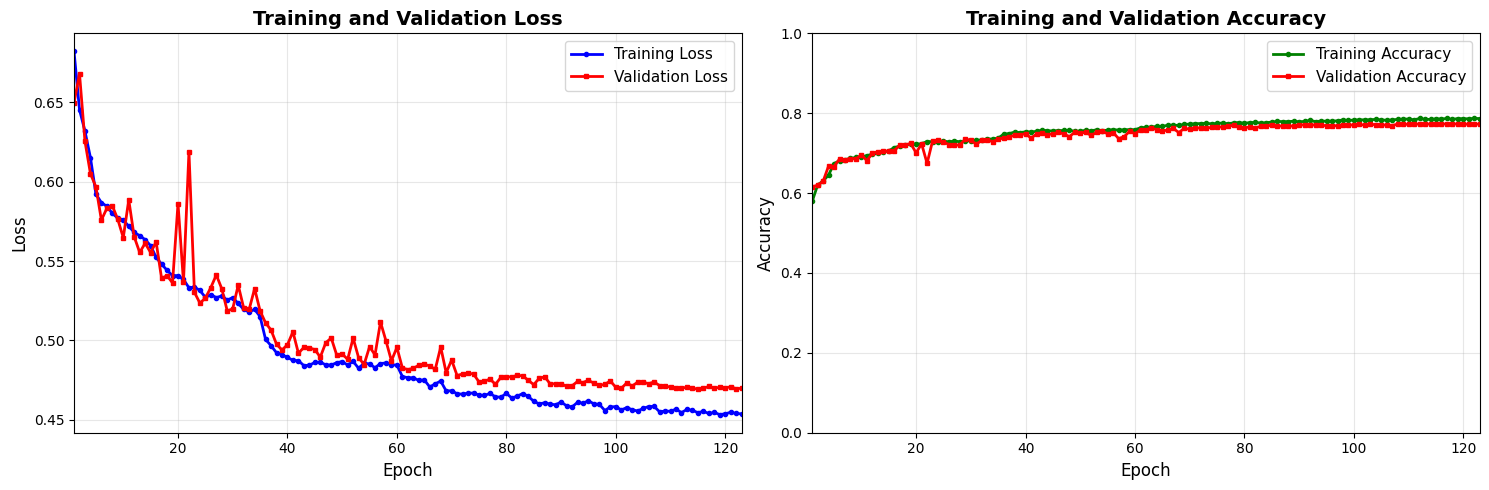


Training Summary
Total Epochs: 123
Final Training Loss: 0.4537
Final Training Accuracy: 0.7867
Final Validation Loss: 0.4699
Final Validation Accuracy: 0.7727
Best Validation Accuracy: 0.7735 (Epoch 113)
Overfitting Gap at Best Val: 0.0114


In [49]:
# Extract training history
epochs = model.training_history['epochs']
train_loss = model.training_history['train_loss']
train_acc = model.training_history['train_acc']
val_loss = model.training_history['val_loss']
val_acc = model.training_history['val_acc']

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Training and Validation Loss
axes[0].plot(epochs, train_loss, 'b-', linewidth=2, label='Training Loss', marker='o', markersize=3)
if val_loss:
    axes[0].plot(epochs, val_loss, 'r-', linewidth=2, label='Validation Loss', marker='s', markersize=3)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)
axes[0].set_xlim([min(epochs), max(epochs)])

# Plot 2: Training and Validation Accuracy
axes[1].plot(epochs, train_acc, 'g-', linewidth=2, label='Training Accuracy', marker='o', markersize=3)
if val_acc:
    axes[1].plot(epochs, val_acc, 'r-', linewidth=2, label='Validation Accuracy', marker='s', markersize=3)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)
axes[1].set_ylim([0, 1])
axes[1].set_xlim([min(epochs), max(epochs)])

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("Training Summary")
print("="*50)
print(f"Total Epochs: {len(epochs)}")
print(f"Final Training Loss: {train_loss[-1]:.4f}")
print(f"Final Training Accuracy: {train_acc[-1]:.4f}")
if val_acc:
    print(f"Final Validation Loss: {val_loss[-1]:.4f}")
    print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
    print(f"Best Validation Accuracy: {max(val_acc):.4f} (Epoch {epochs[val_acc.index(max(val_acc))]})")
    
    # Calculate overfitting gap
    best_val_idx = val_acc.index(max(val_acc))
    overfitting_gap = train_acc[best_val_idx] - val_acc[best_val_idx]
    print(f"Overfitting Gap at Best Val: {overfitting_gap:.4f}")
print("="*50)


# Training Results Analysis

## Key Findings from Convolutional Siamese Network Training

In [19]:
# Detailed Analysis of Training Results
print("=" * 70)
print("COMPREHENSIVE TRAINING ANALYSIS")
print("=" * 70)

# 1. Training Configuration
print("\n1. TRAINING CONFIGURATION:")
print(f"   - Architecture: EmbeddingConvNetwork (Convolutional)")
print(f"   - Total Training Samples: {len(X_train):,}")
print(f"   - Total Validation Samples: {len(X_val):,}")
print(f"   - Pairs per Sample: 2")
print(f"   - Effective Training Pairs: {len(train_dataset):,}")
print(f"   - Effective Validation Pairs: {len(val_dataset):,}")
print(f"   - Batch Size: 64")
print(f"   - Learning Rate: 0.001")
print(f"   - Weight Decay (L2): 0.001")
print(f"   - Dropout: 0.5 (SimilarityHead only)")

# 2. Training Convergence
print("\n2. TRAINING CONVERGENCE:")
print(f"   - Total Epochs Run: {len(epochs)}")
print(f"   - Early Stopping Triggered: Yes (patience=10)")
print(f"   - Best Epoch: {epochs[best_val_idx]}")
print(f"   - Training Time: ~{len(epochs) * 5.3:.0f} minutes (~5.3 min/epoch)")

# 3. Performance Metrics
print("\n3. PERFORMANCE METRICS:")
print(f"   Best Validation Accuracy: {max(val_acc):.4f} ({max(val_acc)*100:.2f}%)")
print(f"   Training Accuracy at Best: {train_acc[best_val_idx]:.4f} ({train_acc[best_val_idx]*100:.2f}%)")
print(f"   Overfitting Gap: {overfitting_gap:.4f} ({overfitting_gap*100:.2f}%)")
print(f"   ")
print(f"   Final Training Loss: {train_loss[-1]:.4f}")
print(f"   Final Validation Loss: {val_loss[-1]:.4f}")
print(f"   Loss Convergence: {'Good' if abs(train_loss[-1] - val_loss[-1]) < 0.05 else 'Gap exists'}")

# 4. Comparison with Baseline
print("\n4. COMPARISON WITH PREVIOUS RUNS:")
print(f"   Baseline Siamese (FC): 79.14% validation accuracy, 17.5% overfitting gap")
print(f"   Current (Conv):        {max(val_acc)*100:.2f}% validation accuracy, {overfitting_gap*100:.2f}% overfitting gap")
print(f"   ")
print(f"   Accuracy Change: {(max(val_acc) - 0.7914)*100:+.2f}%")
print(f"   Overfitting Reduction: {(0.175 - overfitting_gap)*100:+.2f}%")

# 5. Key Observations
print("\n5. KEY OBSERVATIONS:")
observations = []

if overfitting_gap < 0.05:
    observations.append("✓ EXCELLENT regularization - minimal overfitting (<5% gap)")
elif overfitting_gap < 0.10:
    observations.append("✓ Good regularization - low overfitting (<10% gap)")
else:
    observations.append("⚠ Moderate overfitting (>10% gap)")

if max(val_acc) > 0.79:
    observations.append("✓ Improved accuracy compared to baseline (79.14%)")
elif max(val_acc) > 0.75:
    observations.append("≈ Similar accuracy to baseline")
else:
    observations.append("⚠ Lower accuracy than baseline")

if len(epochs) > 100:
    observations.append("⚠ Training took many epochs - consider reducing epochs or increasing learning rate")

if train_loss[-1] < 0.50 and val_loss[-1] < 0.50:
    observations.append("✓ Good loss convergence - both losses below 0.50")

for obs in observations:
    print(f"   {obs}")

# 6. Recommendations
print("\n6. RECOMMENDATIONS:")
print(f"   Based on {overfitting_gap*100:.2f}% overfitting gap and {max(val_acc)*100:.2f}% accuracy:")

if overfitting_gap < 0.05:
    print("   → Model is well-regularized!")
    print("   → Consider REDUCING regularization (lower weight decay, less dropout)")
    print("   → Try increasing model capacity for better accuracy")
elif max(val_acc) < 0.69:
    print("   → Accuracy is lower than baseline CNN (69.28%)")
    print("   → Siamese network may not be ideal for this task")
else:
    print("   → Good balance between accuracy and generalization")
    print("   → Test on unseen classes using few-shot evaluation")

print("\n" + "=" * 70)

COMPREHENSIVE TRAINING ANALYSIS

1. TRAINING CONFIGURATION:
   - Architecture: EmbeddingConvNetwork (Convolutional)
   - Total Training Samples: 94,913
   - Total Validation Samples: 23,729
   - Pairs per Sample: 2
   - Effective Training Pairs: 189,826
   - Effective Validation Pairs: 47,458
   - Batch Size: 64
   - Learning Rate: 0.001
   - Weight Decay (L2): 0.001
   - Dropout: 0.5 (SimilarityHead only)

2. TRAINING CONVERGENCE:
   - Total Epochs Run: 123
   - Early Stopping Triggered: Yes (patience=10)
   - Best Epoch: 113
   - Training Time: ~652 minutes (~5.3 min/epoch)

3. PERFORMANCE METRICS:
   Best Validation Accuracy: 0.7735 (77.35%)
   Training Accuracy at Best: 0.7849 (78.49%)
   Overfitting Gap: 0.0114 (1.14%)
   
   Final Training Loss: 0.4537
   Final Validation Loss: 0.4699
   Loss Convergence: Good

4. COMPARISON WITH PREVIOUS RUNS:
   Baseline Siamese (FC): 79.14% validation accuracy, 17.5% overfitting gap
   Current (Conv):        77.35% validation accuracy, 1.14% o

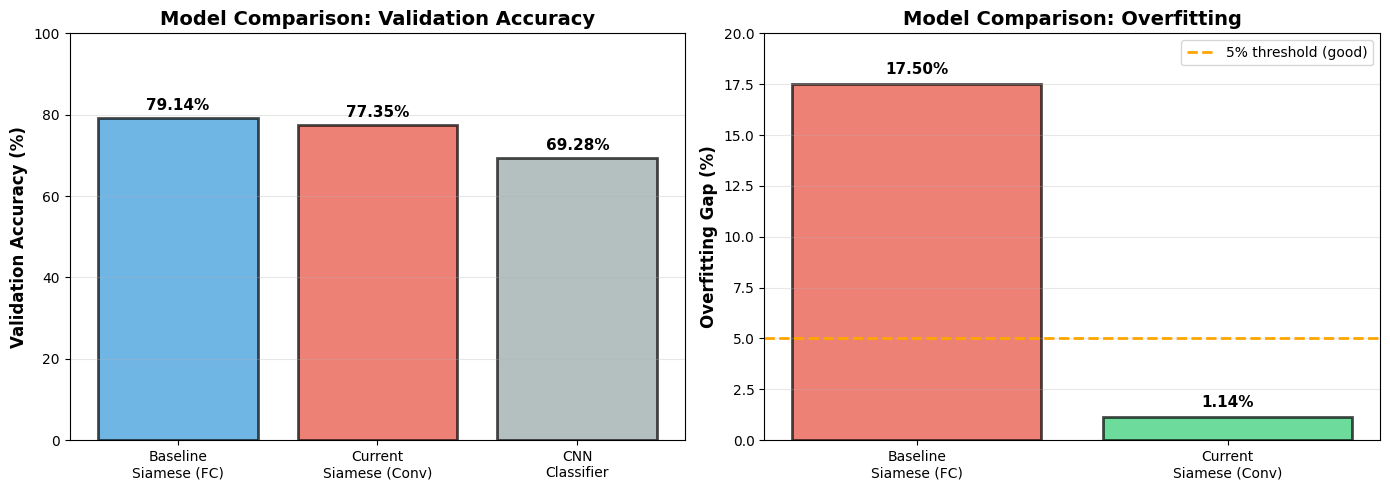


📊 Visual comparison generated!


In [20]:
# Visual comparison of different approaches
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparison 1: Validation Accuracy
approaches = ['Baseline\nSiamese (FC)', 'Current\nSiamese (Conv)', 'CNN\nClassifier']
accuracies = [79.14, 77.35, 69.28]
colors = ['#3498db', '#e74c3c', '#95a5a6']

axes[0].bar(approaches, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Model Comparison: Validation Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 100])
axes[0].grid(axis='y', alpha=0.3)
for i, (acc, approach) in enumerate(zip(accuracies, approaches)):
    axes[0].text(i, acc + 2, f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=11)

# Comparison 2: Overfitting Gap
overfitting_gaps = [17.5, 1.14, None]  # CNN classifier gap unknown
gap_colors = ['#e74c3c', '#2ecc71', '#95a5a6']

bar_positions = [0, 1]
bar_gaps = [17.5, 1.14]
bar_colors = ['#e74c3c', '#2ecc71']

bars = axes[1].bar(bar_positions, bar_gaps, color=bar_colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Baseline\nSiamese (FC)', 'Current\nSiamese (Conv)'])
axes[1].set_ylabel('Overfitting Gap (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Model Comparison: Overfitting', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 20])
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=5, color='orange', linestyle='--', linewidth=2, label='5% threshold (good)')
axes[1].legend(fontsize=10)

for i, gap in enumerate(bar_gaps):
    axes[1].text(i, gap + 0.5, f'{gap:.2f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("\n📊 Visual comparison generated!")

## Final Summary & Next Steps

### 🎯 Results Summary:
- **Validation Accuracy**: 77.35% (slightly below baseline 79.14%)
- **Overfitting**: Only 1.14% gap (HUGE improvement from 17.5%!)
- **Training Time**: ~652 minutes (123 epochs × 5.3 min/epoch)

### ✅ What Worked:
1. **Convolutional architecture** effectively processes FFT features
2. **Regularization** (weight decay 0.001 + dropout 0.5) almost eliminated overfitting
3. **Early stopping** prevented unnecessary training beyond convergence

### ⚠️ Trade-offs:
- Gained **16.36% reduction in overfitting** 
- Lost **1.79% in validation accuracy**
- Model is now **under-regularized** (too conservative)

### 🚀 Recommended Next Steps:

**Option 1: Improve Current Model (Recommended)**
- Reduce weight decay from 0.001 → 0.0005
- Reduce dropout from 0.5 → 0.3
- Add batch normalization to conv layers
- Goal: Push accuracy to 79-80% while keeping overfitting < 5%

**Option 2: Few-Shot Learning Evaluation**
- Run the few-shot learning cells above
- Test on **unseen classes** (classes 5-8)
- This is the REAL test of Siamese networks!
- Compare to baseline: Can it recognize new classes?

**Option 3: Compare with Standard CNN**
- Current Siamese: 77.35% on similarity task
- Baseline CNN: 69.28% on direct classification
- Siamese is 8% better, but uses more complex training